In [325]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [326]:
# Loading the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(url, header=None, names=column_names, na_values=" ?", skipinitialspace=True)

In [327]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [328]:
df["income"].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [329]:
# Separating independent and dependent feature
X = df.drop(["income"], axis=1)
y = df["income"].apply(lambda x: 1 if x==">50K" else 0)

In [330]:
X,y

(       age         workclass  fnlwgt   education  education_num  \
 0       39         State-gov   77516   Bachelors             13   
 1       50  Self-emp-not-inc   83311   Bachelors             13   
 2       38           Private  215646     HS-grad              9   
 3       53           Private  234721        11th              7   
 4       28           Private  338409   Bachelors             13   
 ...    ...               ...     ...         ...            ...   
 32556   27           Private  257302  Assoc-acdm             12   
 32557   40           Private  154374     HS-grad              9   
 32558   58           Private  151910     HS-grad              9   
 32559   22           Private  201490     HS-grad              9   
 32560   52      Self-emp-inc  287927     HS-grad              9   
 
            marital_status         occupation   relationship   race     sex  \
 0           Never-married       Adm-clerical  Not-in-family  White    Male   
 1      Married-civ-spou

In [331]:
# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [332]:
# Defining preprocessor
numeric_features = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_features = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder  (handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [333]:
# Fit preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [334]:
X_train_processed

array([[-0.40875606,  0.08005085,  1.13370219, ...,  1.        ,
         0.        ,  0.        ],
       [-0.1888573 , -0.98165286,  0.35704925, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.42373357,  0.126197  , -1.97290957, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.50824984,  0.25206312, -1.19625663, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.83733689, -1.28762772, -0.41960369, ...,  1.        ,
         0.        ,  0.        ],
       [-0.33545648, -0.59020877,  1.13370219, ...,  1.        ,
         0.        ,  0.        ]])

In [335]:
X_test_processed

array([[-0.84855357, -0.28110745, -0.03127722, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.47083896, -1.32273149, -0.41960369, ...,  1.        ,
         0.        ,  0.        ],
       [-0.7019544 , -0.03659744,  1.13370219, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.61743814,  1.56217302,  1.91035513, ...,  1.        ,
         0.        ,  0.        ],
       [-0.84855357, -1.38844415,  1.13370219, ...,  1.        ,
         0.        ,  0.        ],
       [-1.50824984, -1.55773858, -0.41960369, ...,  1.        ,
         0.        ,  0.        ]])

In [336]:
X_train_processed.shape

(26048, 108)

In [337]:
# Building the regularized model
model = Sequential([
    Dense(128, activation="relu", input_shape=(108,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [338]:
# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [339]:
# Setting up Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

In [340]:
# Training the model
model_history = model.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=50,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8310 - loss: 0.3605 - val_accuracy: 0.8557 - val_loss: 0.3111
Epoch 2/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - loss: 0.3202 - val_accuracy: 0.8562 - val_loss: 0.3065
Epoch 3/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.3146 - val_accuracy: 0.8566 - val_loss: 0.3119
Epoch 4/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8526 - loss: 0.3111 - val_accuracy: 0.8601 - val_loss: 0.3053
Epoch 5/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.3077 - val_accuracy: 0.8570 - val_loss: 0.3056
Epoch 6/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.3045 - val_accuracy: 0.8570 - val_loss: 0.3052
Epoch 7/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8615 - loss: 0.3033 - val_accuracy: 0.8583 - val_loss: 0.3045
Epoch 8/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8613 - loss: 0.3002 - val_accuracy: 0

In [341]:
loss, accuracy = model.evaluate(X_test_processed, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8649 - loss: 0.3026
Test Loss: 0.30259138345718384
Test Accuracy: 0.8648856282234192


In [342]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

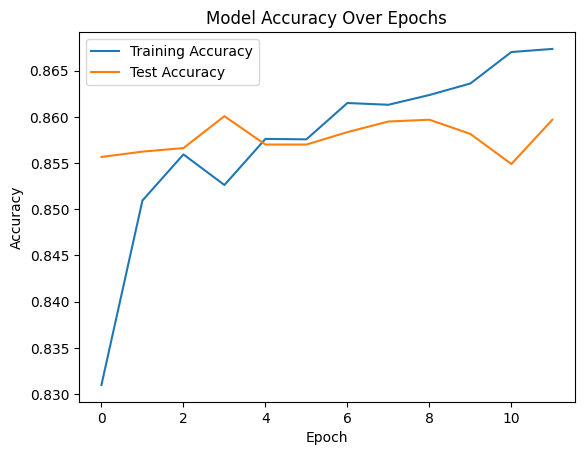

In [343]:
# Plotting training and testing accuracy
plt.plot(model_history.history['accuracy'], label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

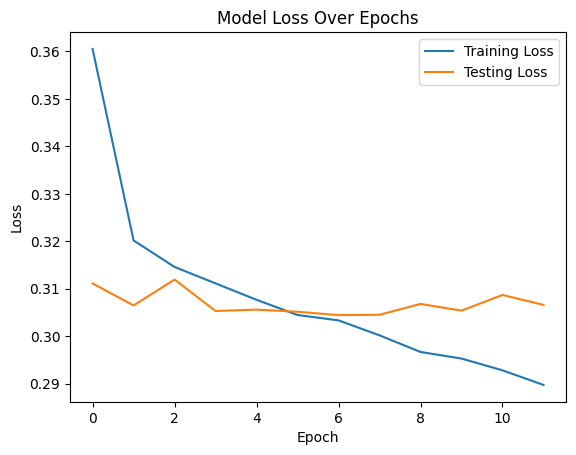

In [344]:
# Plotting training and testing loss
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Testing Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [345]:
# Predicting the test set
y_pred = model.predict(X_test_processed)
y_pred = (y_pred >= 0.5).astype(int)
y_pred

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0],
       [1],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [346]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8648856133886074


In [347]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      4942
           1       0.74      0.69      0.71      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.80      0.81      6513
weighted avg       0.86      0.86      0.86      6513



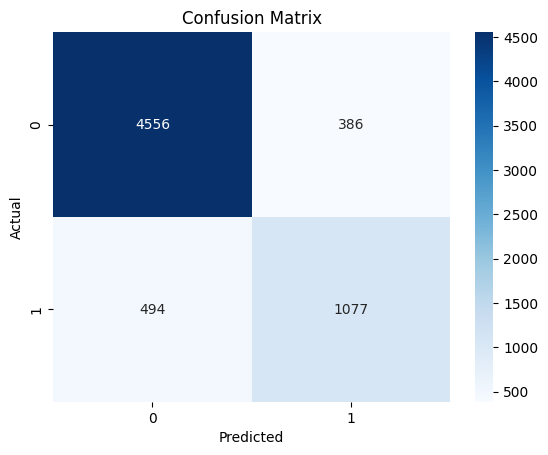

In [348]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [349]:
# ROC-AUC score
y_prob = model.predict(X_test_processed)
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC-AUC: 0.9168345165472633


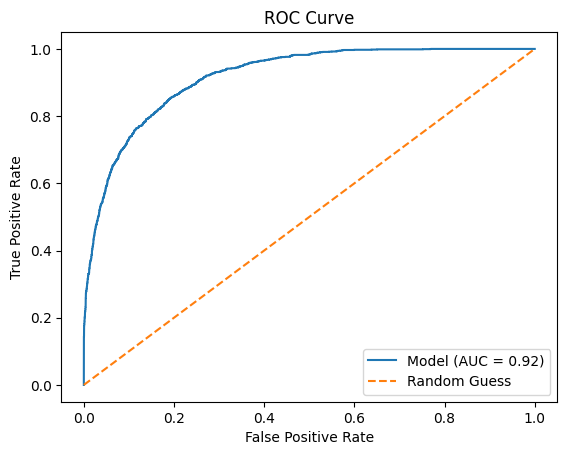

In [350]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Model (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()